In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import json
import pandas as pd
import random
import datetime
from tqdm import tqdm
from utils import geo_to_mercator, mercator_to_geo

import cv2
# from h3.unstable import vect
# import h3.api.numpy_int as h3
import h3


In [ ]:

geo_prior_fp = "geo_prior_train.csv"
geo_prior_data = pd.read_csv(geo_prior_fp)
geo_prior_data = geo_prior_data.drop('quality_grade', axis=1)   # drop quality_grade since all are "research"
geo_prior_data = geo_prior_data.drop('positional_accuracy', axis=1)   # drop positional_accuracy since not really needed (and most are NaN)
geo_prior_data.shape

KeyboardInterrupt: 

In [3]:
geo_prior_data['observed_on'] = pd.to_datetime(geo_prior_data['observed_on'], format='%Y-%m-%d') 
geo_prior_data['year'] = pd.to_datetime(geo_prior_data['observed_on']).dt.strftime('%Y').astype(int)

geo_prior_data = geo_prior_data[geo_prior_data["year"]>=2017]     # only get from 2017 since we only have Sentinel-2B data starting 2017
geo_prior_data.head()

,observation_uuid,observer_id,latitude,longitude,taxon_id,observed_on,year
57496,1710b9ff-8b59-48bd-986e-b3b34206ec59,11318,18.747490,73.403442,114466,2017-02-13,2017
62722,f9bf2f46-6eb3-49c6-ab01-821f1b4d53b0,13078,30.498187,-95.713390,29925,2019-03-16,2019
110040,e9ee9a33-f783-42d5-9ab4-c3afaa3b2dc9,18624,35.212859,-85.904978,133354,2019-05-10,2019
110047,7ffecb87-62cc-4a1f-b7f4-0ffcf1298933,18624,35.212859,-85.904978,57056,2017-11-27,2017
115447,28ac9fb8-c8ff-427a-923a-76a29c284bf2,19093,37.992943,-122.975464,50840,2018-05-22,2018


In [4]:
geo_prior_data.to_csv("filtered_geo_prior_data.csv", index=False)

In [8]:
# Dedupe based on taxon_id-lat-lon
geo_prior_data["taxon_id-lat-lon"] =  geo_prior_data[["taxon_id", "latitude", "longitude"]].apply(lambda row: '_'.join(row.values.astype(str)), axis=1)


In [9]:
deduped = geo_prior_data.groupby("taxon_id-lat-lon").head(1)
deduped.shape

(29829795, 8)

In [10]:
deduped.to_csv("deduped_filtered_geo_prior_data.csv", index=False)

In [7]:
geo_prior_data.shape

(31520093, 7)

In [11]:
deduped["taxon_id"].value_counts()

taxon_id
6930      121519
47219     116552
48662      96143
48484      81931
4956       78553
           ...  
102102         2
761406         2
446326         1
521039         1
759171         1
Name: count, Length: 47373, dtype: int64

In [5]:
def assign_h3_cell(lat, lon, resolution=6):
    h3_cell = h3.geo_to_h3(lat, lon, resolution)    # uses h3 version 3.7.7
    return h3_cell

In [26]:
# Assign h3 cell number given lat and lon in inat observations ()
deduped["h3_res6"] = deduped.apply(lambda x: assign_h3_cell(x["latitude"], x["longitude"], resolution=6), axis=1)

/tmp/ipykernel_3426573/3500490560.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  deduped["h3_res6"] = deduped.apply(lambda x: assign_h3_cell(x["latitude"], x["longitude"], resolution=6), axis=1)


In [27]:
deduped.to_csv("deduped_filtered_geo_prior_data.csv", index=False)

In [28]:
deduped["h3_res7"] = deduped.apply(lambda x: assign_h3_cell(x["latitude"], x["longitude"], resolution=7), axis=1)
deduped.to_csv("deduped_filtered_geo_prior_data.csv", index=False)

/tmp/ipykernel_3426573/2949396659.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  deduped["h3_res7"] = deduped.apply(lambda x: assign_h3_cell(x["latitude"], x["longitude"], resolution=7), axis=1)


In [2]:
# Assign h3 cell number given lat and lon in satellite tiles in data/sentinel2_good_files_withlatlon.csv
sentinel_df = pd.read_csv("data/sentinel2_good_files_withlatlon.csv")
sentinel_df.shape

(9860254, 10)

In [3]:
sentinel_df = sentinel_df[sentinel_df["year"]>=2017]
deduped_sentinel_df = sentinel_df.groupby("lon-lat").head(1)    # means there are duplicate locations across years
deduped_sentinel_df.shape

(950486, 10)

In [8]:
sentinel_df.shape

(9859878, 10)

In [6]:
deduped_sentinel_df["h3_res6"] = deduped_sentinel_df.apply(lambda x: assign_h3_cell(x["latitude"], x["longitude"], resolution=6), axis=1)
deduped_sentinel_df["h3_res7"] = deduped_sentinel_df.apply(lambda x: assign_h3_cell(x["latitude"], x["longitude"], resolution=7), axis=1)

/tmp/ipykernel_3431392/4110913729.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  deduped_sentinel_df["h3_res6"] = deduped_sentinel_df.apply(lambda x: assign_h3_cell(x["latitude"], x["longitude"], resolution=6), axis=1)
/tmp/ipykernel_3431392/4110913729.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  deduped_sentinel_df["h3_res7"] = deduped_sentinel_df.apply(lambda x: assign_h3_cell(x["latitude"], x["longitude"], resolution=7), axis=1)


In [ ]:
deduped_sentinel_df.to_csv("deduped_sentinel2_good_files_withlatlon.csv", index=False)
deduped_sentinel_df = pd.read_csv("deduped_sentinel2_good_files_withlatlon.csv")

In [4]:
deduped = pd.read_csv("deduped_filtered_geo_prior_data.csv")

In [5]:
# Merge sentinel and inat obs based on h3 cell (try with both res6 and res7)
merged_df = deduped_sentinel_df.merge(deduped, how = 'inner', on = ['h3_res7'])
merged_df.shape

(9119396, 21)

In [7]:
merged_df["taxon_id-lat-lon"].value_counts()

taxon_id-lat-lon
14850.0_58.5122300919_49.6420251906          2
5268.0_58.527709933_49.6380497581            2
13695.0_58.525059353500005_49.6412201513     2
12707.0_58.5228002504_49.6424086434          2
145360.0_58.522006498900005_49.6431213049    2
                                            ..
99891.0_40.3308192_-74.9423529001            1
61495.0_40.3307649_-74.9424947001            1
61495.0_40.3307784_-74.9425002               1
104580.0_40.3308392001_-74.9424072           1
81559.0_40.3285954_-74.9437191               1
Name: count, Length: 9117657, dtype: int64

In [6]:
merged_df.head()

,fp,datetime,year_x,month,day,col,row,lon-lat,longitude_x,latitude_x,...,h3_res7,observation_uuid,observer_id,latitude_y,longitude_y,taxon_id,observed_on,year_y,taxon_id-lat-lon,h3_res6_y
0,S2A_MSIL1C_20221126T142711_N0400_R053_T19GCQ_2...,20221126T142711,2022,11,26,2472,5126,"(-71.34521484375, -41.19518774143978)",-71.345215,-41.195188,...,87ce8548bffffff,41333f93-f88b-46ae-82a7-893f782efacf,4474329,-41.184574,-71.338969,1289529,2020-03-20,2020,1289529.0_-41.1845741946_-71.338968704,86ce80b27ffffff
1,S2A_MSIL1C_20221126T142711_N0400_R053_T19GCQ_2...,20221126T142711,2022,11,26,2472,5126,"(-71.34521484375, -41.19518774143978)",-71.345215,-41.195188,...,87ce8548bffffff,81add6cc-d677-472d-add9-8c6aeac7fdc9,4474329,-41.184574,-71.338969,4765,2021-07-12,2021,4765.0_-41.1845741946_-71.338968704,86ce80b27ffffff
2,S2A_MSIL1C_20220111T102411_N0301_R065_T32TMQ_2...,20220111T102411,2022,1,11,4287,2953,"(8.41552734375, 44.793528798196796)",8.415527,44.793529,...,871f9bd71ffffff,41181714-2a26-49b8-b741-9e22ff6e8126,1047456,44.795740,8.421945,57470,2020-04-27,2020,57470.0_44.7957403_8.4219447,861f9bd77ffffff
3,S2A_MSIL1C_20220111T102411_N0301_R065_T32TMQ_2...,20220111T102411,2022,1,11,4287,2953,"(8.41552734375, 44.793528798196796)",8.415527,44.793529,...,871f9bd71ffffff,0dace24b-54e7-4b6c-adb8-ba7cac2d681e,112445,44.779756,8.428464,40645,2020-12-16,2020,40645.0_44.7797562691_8.428464072799999,861f9bd77ffffff
4,S2A_MSIL1C_20220111T102411_N0301_R065_T32TMQ_2...,20220111T102411,2022,1,11,4287,2953,"(8.41552734375, 44.793528798196796)",8.415527,44.793529,...,871f9bd71ffffff,abcba81c-2dc9-471a-8396-5b67f095cd08,1047456,44.796762,8.427869,59321,2021-04-27,2021,59321.0_44.7967621_8.4278688,861f9bd77ffffff


# Testing merged data (run cells from here onwards only after 00e script)

In [8]:
merged_df.to_csv("merged_h3res7_sinr_sentinel.csv", index=False)

In [9]:
merged_df["taxon_id-h3_res7"] =  merged_df[["taxon_id", "h3_res7"]].apply(lambda row: '_'.join(row.values.astype(str)), axis=1)

In [10]:
merged_df["taxon_id-h3_res7"].value_counts()    # number of unique entries is size of dataset (minus species with no text embedding after merging with text embedding)

taxon_id-h3_res7
9083_8744d8161ffffff      997
23951_872e60c71ffffff     937
114622_87be631b6ffffff    924
46017_872a306e5ffffff     921
517449_87ad368ceffffff    893
                         ... 
7168_876619644ffffff        1
979968_876619644ffffff      1
9921_876619644ffffff        1
6597_876619644ffffff        1
5196_876619644ffffff        1
Name: count, Length: 5056181, dtype: int64

In [4]:

from geopandas import GeoDataFrame

import pandas as pd
from shapely.geometry import Point
import geopandas as gpd
import matplotlib

In [7]:
merged_df = pd.read_csv("merged_df_res9.csv")
merged_df.shape

(189138, 26)

In [5]:
geog_df = merged_df[["latitude_x", "longitude_x", "year_x"]]

In [7]:
merged_df.shape

(1299923, 26)

In [9]:
merged_df.columns

Index(['fp', 'datetime', 'year_x', 'month', 'day', 'col', 'row', 'lon-lat',
       'longitude_x', 'latitude_x', 'h3_res6_x', 'h3_res7_x', 'h3_res8',
       'h3_res9_x', 'observation_uuid', 'observer_id', 'latitude_y',
       'longitude_y', 'taxon_id', 'observed_on', 'year_y', 'taxon_id-lat-lon',
       'h3_res6_y', 'h3_res7_y', 'h3_res9_y', 'taxon_id-h3_res8'],
      dtype='object')

/tmp/ipykernel_1513780/3854814010.py:6: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))


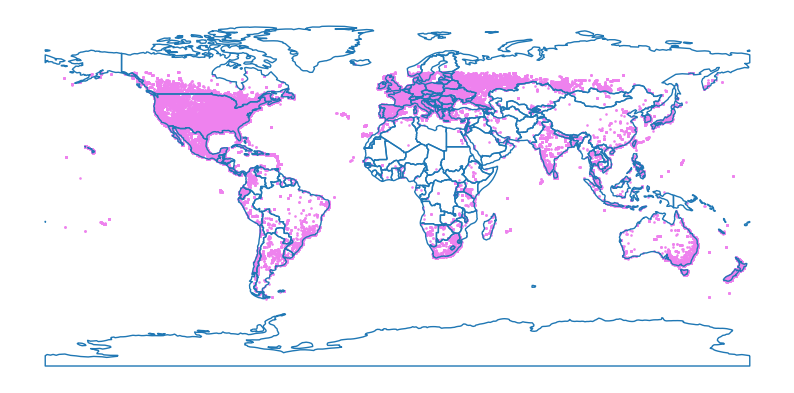

In [8]:
# plot of spatial data distribution of res 7 data points
geometry = [Point(xy) for xy in zip(geog_df['longitude_x'], geog_df['latitude_x'])]
gdf = GeoDataFrame(geog_df, geometry=geometry)   

#this is a simple map that goes with geopandas
world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))

ax = world.boundary.plot(figsize=(10, 6), linewidth=1)
# gdf.plot(ax=ax, marker='.', column="year_x",markersize=3, legend=False, vmin=0, vmax=2024)  # green, violet, yellow
gdf.plot(ax=ax, marker='.', color="violet",markersize=3, legend=False)  # green, violet, yellow


plt.axis('off')
plt.show()

# Plot Distribution of Training Data

In [2]:

from geopandas import GeoDataFrame

import pandas as pd
from shapely.geometry import Point
import geopandas as gpd
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

In [3]:
metadata_path = "data/dataloader_data_merged_df_res9_withtextidx_timeaugs.npy"

with open(metadata_path, "rb") as f:
    data = np.load(f, allow_pickle=True)[()]["dataloader_data"]

In [8]:
all_data = []
all_fns = []
for group in tqdm(data):
    for d in group:
        sat_fp, lon, lat, _, aug_fns = d
        all_fns.append(sat_fp)
        all_fns += aug_fns
        all_data.append([sat_fp, lon, lat])
geog_df = pd.DataFrame(all_data, columns=["sat_fp", "longitude", "latitude"])

100%|██████████| 134890/134890 [00:01<00:00, 70551.26it/s]


In [ ]:
all_sat_fp = geog_df["sat_fp"].values
unique_sat_fp = np.unique(all_sat_fp)


(29167,)

In [13]:
merged_df.head()

,fp,datetime,year_x,month,day,col,row,lon-lat,longitude_x,latitude_x,...,latitude_y,longitude_y,taxon_id,observed_on,year_y,taxon_id-lat-lon,h3_res6_y,h3_res7_y,h3_res8_y,taxon_id-h3_res9
0,S2B_MSIL1C_20220507T012649_N0400_R074_T54STF_2...,20220507T012649,2022,5,7,7235,3209,"(137.96630859375, 36.26199019508963)",137.966309,36.261990,...,36.261538,137.969305,124566,2021-11-08,2021,124566.0_36.2615380317_137.9693049565,862e75047ffffff,872e75071ffffff,882e750713fffff,124566_892e7504693ffff
1,S2B_MSIL1C_20220507T012649_N0400_R074_T54STF_2...,20220507T012649,2022,5,7,7235,3209,"(137.96630859375, 36.26199019508963)",137.966309,36.261990,...,36.261355,137.969205,367801,2021-11-10,2021,367801.0_36.2613549173_137.9692050072,862e75047ffffff,872e75071ffffff,882e750713fffff,367801_892e7504693ffff
2,S2A_MSIL1C_20220114T103401_N0301_R108_T32TLT_2...,20220114T103401,2022,1,14,4265,2859,"(7.44873046875, 47.6505854735957)",7.448730,47.650585,...,47.649633,7.450658,55811,2020-12-31,2020,55811.0_47.6496333333_7.450658333300001,861f83917ffffff,871f83914ffffff,881f839149fffff,55811_891f839148bffff
3,S2A_MSIL1C_20221124T183711_N0400_R027_T11SLT_2...,20221124T183711,2022,11,24,1409,3271,"(-118.05908203125, 34.034450655521496)",-118.059082,34.034451,...,34.035417,-118.059568,4364,2018-01-28,2018,4364.0_34.0354173625_-118.0595682207,8629a1d17ffffff,8729a1d15ffffff,8829a1d153fffff,4364_8929a1d1527ffff
4,S2A_MSIL1C_20221124T183711_N0400_R027_T11SLT_2...,20221124T183711,2022,11,24,1409,3271,"(-118.05908203125, 34.034450655521496)",-118.059082,34.034451,...,34.036068,-118.061760,9100,2018-04-30,2018,9100.0_34.0360683333_-118.06176,8629a1d17ffffff,8729a1d02ffffff,8829a1d025fffff,9100_8929a1d1527ffff


In [17]:
filtered_data = []
for uni_sat_fp in tqdm(unique_sat_fp):
    row = merged_df[(merged_df["fp"]==uni_sat_fp)]
    # assert len(row)==1, print(row)    # there could be multiple since multiple species can be associated to same satellite image
    filtered_data.append(row)
    # break

100%|██████████| 29167/29167 [06:36<00:00, 73.52it/s]


In [18]:
filtered_df = pd.concat(filtered_data)
filtered_df.shape

(188400, 26)

In [19]:
df_w_text = pd.read_csv("data/merged_df_res9_withtextidx.csv")

In [25]:
df_w_text.head()

,text_emb_idx,taxon_id,section_name,fp,datetime,year_x,month,day,col,row,...,observer_id,latitude_y,longitude_y,observed_on,year_y,taxon_id-lat-lon,h3_res6_y,h3_res7_y,h3_res8_y,taxon_id-h3_res9
0,6,13791,text,S2A_MSIL1C_20220601T113331_N0400_R080_T27PZS_2...,20220601T113331,2022,6,1,3699,3758,...,83785,14.668830,-17.426738,2020-01-18,2020,13791.0_14.66883_-17.426738333299998,8654ac2efffffff,8754ad5b6ffffff,8854ad5b6dfffff,13791_8954ad5b6c3ffff
1,7,16798,text,S2A_MSIL1C_20220425T151711_N0400_R125_T19QEA_2...,20220425T151711,2022,4,25,2539,3663,...,2564851,18.667145,-68.402563,2020-01-31,2020,16798.0_18.667145_-68.4025633333,864cc610fffffff,874cc610affffff,884cc610adfffff,16798_894cc610ad7ffff
2,7,16798,text,S2B_MSIL1C_20220617T155829_N0400_R097_T17RLK_2...,20220617T155829,2022,6,17,2227,3468,...,1882354,26.570488,-82.110992,2021-04-28,2021,16798.0_26.5704883333_-82.1109916667,864413337ffffff,874413333ffffff,8844133331fffff,16798_89441333307ffff
3,7,16798,text,S2A_MSIL1C_20220130T160511_N0400_R054_T17RNJ_2...,20220130T160511,2022,1,30,2270,3489,...,375168,25.739886,-80.223330,2020-06-22,2020,16798.0_25.7398864291_-80.2233297051,8644a18d7ffffff,8744a18d3ffffff,8844a18d37fffff,16798_8944a18d367ffff
4,8,16798,Taxonomy,S2A_MSIL1C_20220425T151711_N0400_R125_T19QEA_2...,20220425T151711,2022,4,25,2539,3663,...,2564851,18.667145,-68.402563,2020-01-31,2020,16798.0_18.667145_-68.4025633333,864cc610fffffff,874cc610affffff,884cc610adfffff,16798_894cc610ad7ffff


In [26]:
df_w_text.columns

Index(['text_emb_idx', 'taxon_id', 'section_name', 'fp', 'datetime', 'year_x',
       'month', 'day', 'col', 'row', 'lon-lat', 'longitude_x', 'latitude_x',
       'h3_res6_x', 'h3_res7_x', 'h3_res8_x', 'h3_res9', 'observation_uuid',
       'observer_id', 'latitude_y', 'longitude_y', 'observed_on', 'year_y',
       'taxon_id-lat-lon', 'h3_res6_y', 'h3_res7_y', 'h3_res8_y',
       'taxon_id-h3_res9'],
      dtype='object')

In [34]:
df_w_text["text_emb_idx"].value_counts()

11351     1064
11356     1064
11354     1064
11355     1064
11352     1064
          ... 
127378       1
36           1
8933         1
8934         1
8935         1
Name: text_emb_idx, Length: 70733, dtype: int64

In [33]:
df_w_text["lon-lat"].value_counts()

(-75.65185546875, 45.444714685247384)    19788
(-60.31494140625, 46.21024749546477)     12062
(10.17333984375, 54.30370244341415)       8846
(-118.14697265625, 34.21634272932354)     6751
(-77.18994140625, 38.66835404615575)      6205
                                         ...  
(-71.96044921875, 45.47553816527416)         1
(-96.56982421875, 33.22949621017061)         1
(-78.72802734375, 43.11702201929734)         1
(-77.76123046875, 44.103363272341255)        1
(-89.27490234375, 44.60611063877104)         1
Name: lon-lat, Length: 29221, dtype: int64

In [31]:
df_w_text["year_y"].value_counts()

2021    358586
2020    303407
2019    170594
2018     92200
2017     57114
Name: year_y, dtype: int64

In [22]:
df_w_text["taxon_id-h3_res9"].value_counts()

9744_892b83b2a1bffff       1440
65982_892b83b2a1bffff      1300
145310_892b83b2a1bffff     1176
48662_892aa869173ffff       992
63134_891f0601523ffff       936
                           ... 
1368641_8948a200c67ffff       1
1368641_8948a205adbffff       1
1368641_8926cbd8a2fffff       1
1368641_89489c1623bffff       1
1368641_89264a6a227ffff       1
Name: taxon_id-h3_res9, Length: 135140, dtype: int64

In [24]:
df_w_text["taxon_id"].value_counts()

48662      9872
47219      9321
6930       8512
13858      5499
9744       5040
           ... 
1255700       1
334250        1
336264        1
333937        1
56987         1
Name: taxon_id, Length: 19571, dtype: int64

In [6]:
len(all_fns), len(np.unique(all_fns))

(10316854, 305689)

In [19]:
geog_df[["longitude", "latitude"]].value_counts()

longitude    latitude 
-75.651855   45.444715    19788
-60.314941   46.210247    12062
 10.173340   54.303702     8846
-118.146973  34.216343     6751
-77.189941   38.668354     6205
                          ...  
-120.124512  39.044784        1
-120.168457  41.885919        1
             39.283292        1
 19.797363   45.166545        1
 1.384277    42.147112        1
Length: 29167, dtype: int64

/tmp/ipykernel_1514524/2058371472.py:6: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))


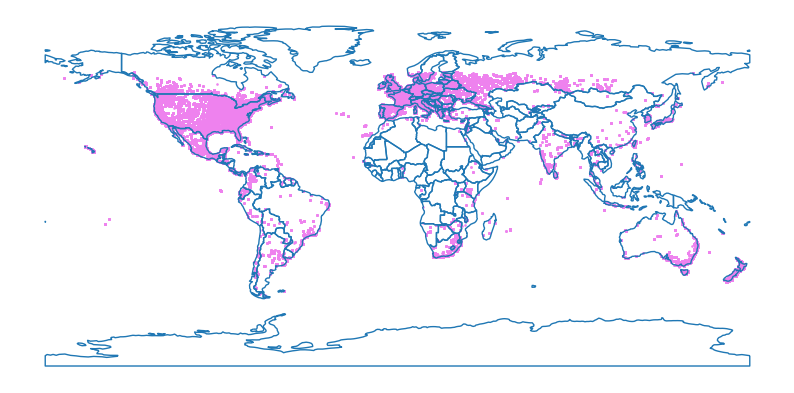

In [14]:
# plot of spatial data distribution of res 7 data points
geometry = [Point(xy) for xy in zip(geog_df['longitude'], geog_df['latitude'])]
gdf = GeoDataFrame(geog_df, geometry=geometry)   

#this is a simple map that goes with geopandas
world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))

ax = world.boundary.plot(figsize=(10, 6), linewidth=1)
# gdf.plot(ax=ax, marker='.', column="year_x",markersize=3, legend=False, vmin=0, vmax=2024)  # green, violet, yellow
gdf.plot(ax=ax, marker='.', color="violet", markersize=3, legend=False)  # green, violet, yellow


plt.axis('off')
plt.savefig(f"data_distribution.png", bbox_inches="tight", dpi=300)
plt.show()

In [24]:

plt.savefig(f"data_distribution.png", bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

In [19]:
geog_df.shape

(980376, 2)

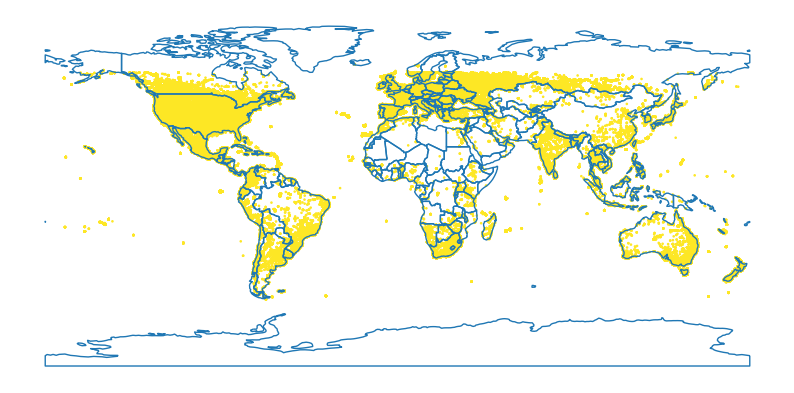

In [18]:
# res 7 distribution of satellite images